# Rule-Based Baseline (V2)

A hand-crafted classifier using velocity, movement, and spin thresholds.
Built on the v2 test set (all MLB pitchers, 9 classes) to serve as a
comparison baseline for the ML models.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score

X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

df = X_train.copy()
df['pitch_type'] = y_train

print(f'Test set: {len(X_test)} rows')
print(f'Classes: {sorted(y_test.unique())}')


Test set: 18000 rows
Classes: ['CH', 'CU', 'FC', 'FF', 'FS', 'KC', 'SI', 'SL', 'ST']


,release_speed_mean,release_speed_min,release_speed_max,pfx_x_mean,pfx_x_min,pfx_x_max,pfx_z_mean,pfx_z_min,pfx_z_max,release_spin_rate_mean,release_spin_rate_min,release_spin_rate_max,spin_axis_mean,spin_axis_min,spin_axis_max
pitch_type,,,,,,,,,,,,,,,
CH,85.42,50.8,95.0,-0.38,-2.22,1.88,0.48,-0.94,1.66,1791.75,666.0,2893.0,198.38,16.0,350.0
CU,78.96,62.7,88.4,0.32,-1.97,1.94,-0.82,-2.06,0.82,2545.15,1121.0,3482.0,129.26,0.0,360.0
FC,89.13,74.6,102.3,0.13,-1.02,1.66,0.63,-0.71,1.79,2388.25,1280.0,3067.0,178.86,5.0,357.0
FF,94.21,70.4,103.3,-0.27,-1.68,1.75,1.31,-0.85,1.97,2285.23,1139.0,2992.0,194.48,38.0,357.0
FS,86.44,72.1,96.8,-0.85,-2.21,1.57,0.28,-0.84,1.50,1352.22,299.0,2720.0,230.68,1.0,355.0
KC,81.74,70.9,91.9,0.50,-1.64,1.80,-0.79,-2.03,0.62,2460.14,706.0,3315.0,81.11,0.0,360.0
SI,93.37,81.0,103.7,-0.53,-2.17,2.03,0.66,-1.44,2.05,2147.12,1075.0,2949.0,198.53,10.0,343.0
SL,85.47,63.0,95.3,0.20,-2.05,1.97,0.13,-1.23,1.78,2396.02,724.0,3265.0,143.76,0.0,360.0
ST,81.69,65.8,90.3,0.62,-2.27,2.25,0.10,-1.29,1.26,2538.96,1115.0,3492.0,116.39,10.0,359.0


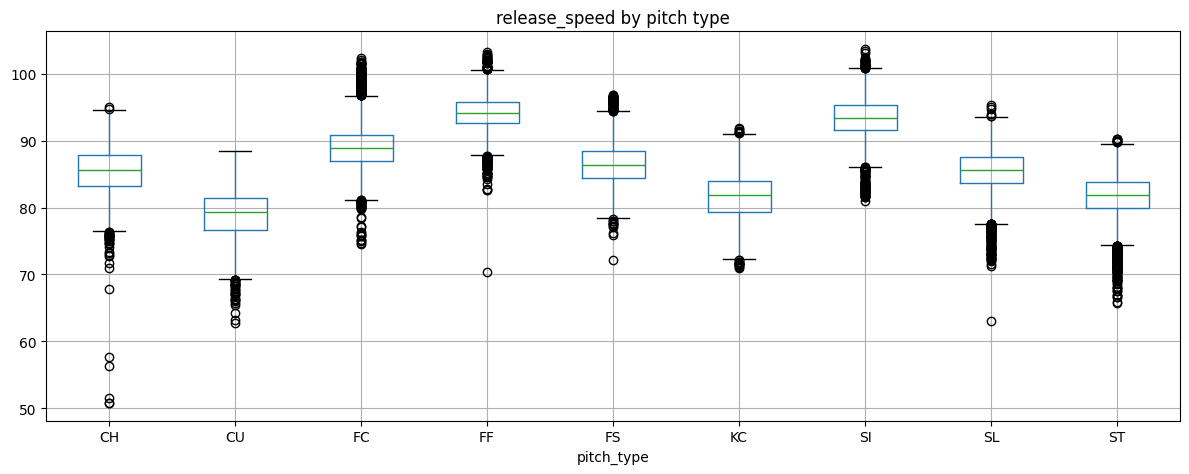

In [2]:
df.groupby('pitch_type').mean().round(2)

feature = 'release_speed'  # change to explore: pfx_x, pfx_z, release_spin_rate, spin_axis, etc.

cols = ['release_speed', 'pfx_x', 'pfx_z', 'release_spin_rate', 'spin_axis']

summary = df.groupby('pitch_type')[cols].agg(['mean', 'min', 'max']).round(2)
summary.columns = ['_'.join(col) for col in summary.columns]
display(summary)

df.boxplot(column=feature, by='pitch_type', figsize=(12, 5))
plt.title(f'{feature} by pitch type')
plt.suptitle('')
plt.tight_layout()
plt.show()


In [3]:
means = df.groupby('pitch_type')[['release_speed', 'pfx_z', 'spin_axis', 'release_spin_rate']].mean()

# velocity midpoints
thresh_speed_ff   = (means.loc['SI', 'release_speed'] + means.loc['FC', 'release_speed']) / 2
thresh_speed_fc   = (means.loc['FC', 'release_speed'] + means.loc['CH', 'release_speed']) / 2
thresh_speed_soft = (means.loc['KC', 'release_speed'] + means.loc['CH', 'release_speed']) / 2

# pfx_z threshold between fastballs and breaking balls
thresh_pfxz_break = (means.loc['FC', 'pfx_z'] + means.loc['KC', 'pfx_z']) / 2

# spin_axis thresholds
thresh_axis_kc_st  = (means.loc['KC',  'spin_axis'] + means.loc['ST',  'spin_axis']) / 2
thresh_axis_st_cu  = (means.loc['ST',  'spin_axis'] + means.loc['CU',  'spin_axis']) / 2
thresh_axis_cu_sl  = (means.loc['CU',  'spin_axis'] + means.loc['SL',  'spin_axis']) / 2
thresh_axis_sl_ff  = (means.loc['SL',  'spin_axis'] + means.loc['FC',  'spin_axis']) / 2
thresh_axis_ff_fs  = (means.loc['SI',  'spin_axis'] + means.loc['FS',  'spin_axis']) / 2

# spin_rate thresholds
thresh_spin_fs  = (means.loc['FS', 'release_spin_rate'] + means.loc['CH', 'release_spin_rate']) / 2
thresh_spin_ch  = (means.loc['CH', 'release_spin_rate'] + means.loc['SI', 'release_spin_rate']) / 2

print(f'speed_ff:    {thresh_speed_ff:.1f}')
print(f'speed_fc:    {thresh_speed_fc:.1f}')
print(f'speed_soft:  {thresh_speed_soft:.1f}')
print(f'pfxz_break:  {thresh_pfxz_break:.2f}')
print(f'axis_kc_st:  {thresh_axis_kc_st:.1f}')
print(f'axis_st_cu:  {thresh_axis_st_cu:.1f}')
print(f'axis_cu_sl:  {thresh_axis_cu_sl:.1f}')
print(f'axis_sl_ff:  {thresh_axis_sl_ff:.1f}')
print(f'axis_ff_fs:  {thresh_axis_ff_fs:.1f}')
print(f'spin_fs:     {thresh_spin_fs:.1f}')
print(f'spin_ch:     {thresh_spin_ch:.1f}')


speed_ff:    91.2
speed_fc:    87.3
speed_soft:  83.6
pfxz_break:  -0.08
axis_kc_st:  98.8
axis_st_cu:  122.8
axis_cu_sl:  136.5
axis_sl_ff:  161.3
axis_ff_fs:  214.6
spin_fs:     1572.0
spin_ch:     1969.4


In [4]:
def rule_based_classifier(row):
    speed     = row['release_speed']
    pfx_z     = row['pfx_z']
    spin      = row['release_spin_rate']
    spin_axis = row['spin_axis']

    thresh_pfxz_ff_si  = (means.loc['FF', 'pfx_z']      + means.loc['SI', 'pfx_z'])      / 2
    thresh_pfxz_break  = (means.loc['SL', 'pfx_z']      + means.loc['KC', 'pfx_z'])      / 2
    thresh_axis_kc_cu  = (means.loc['KC', 'spin_axis']   + means.loc['CU', 'spin_axis'])  / 2
    thresh_axis_st_sl  = (means.loc['ST', 'spin_axis']   + means.loc['SL', 'spin_axis'])  / 2
    thresh_axis_sl_fc  = (means.loc['SL', 'spin_axis']   + means.loc['FC', 'spin_axis'])  / 2
    thresh_speed_kc_cu = (means.loc['KC', 'release_speed'] + means.loc['CU', 'release_speed']) / 2

    # breaking balls
    if pfx_z < thresh_pfxz_break:
        if spin_axis < thresh_axis_kc_cu and speed >= thresh_speed_kc_cu:
            return 'KC'
        return 'CU'

    # fastball family
    if speed >= thresh_speed_ff:
        if pfx_z > thresh_pfxz_ff_si:
            return 'FF'
        return 'SI'

    if speed >= thresh_speed_fc:
        if spin_axis < thresh_axis_sl_fc:
            return 'SL'
        return 'FC'

    # offspeed / lateral group
    if spin < thresh_spin_fs:
        return 'FS'
    if spin < thresh_spin_ch:
        return 'CH'
    if spin_axis < thresh_axis_st_sl:
        return 'ST'
    return 'SL'


In [5]:
y_pred = X_test.apply(rule_based_classifier, axis=1)

print(classification_report(y_test, y_pred))
print(f'Weighted F1: {f1_score(y_test, y_pred, average="weighted"):.4f}')

df_test = X_test.copy()
df_test['y_true'] = y_test.values
df_test['y_pred'] = y_pred.values

# for each true class, show the distribution of predicted classes
misclassified = df_test[df_test['y_true'] != df_test['y_pred']]
print(misclassified.groupby(['y_true', 'y_pred']).size().unstack(fill_value=0))

target_class = 'CU'  # change to investigate other classes

wrong = df_test[(df_test['y_true'] == target_class) & (df_test['y_pred'] != target_class)]
print(f'\n Misclassified {target_class} pitches: {len(wrong)}')
print(wrong[['release_speed', 'pfx_z', 'release_spin_rate', 'spin_axis', 'y_pred']].describe().round(2))


              precision    recall  f1-score   support

          CH       0.63      0.31      0.41      2000
          CU       0.57      0.62      0.59      2000
          FC       0.32      0.39      0.36      2000
          FF       0.79      0.81      0.80      2000
          FS       0.73      0.48      0.58      2000
          KC       0.59      0.53      0.56      2000
          SI       0.65      0.62      0.64      2000
          SL       0.29      0.42      0.34      2000
          ST       0.51      0.64      0.57      2000

    accuracy                           0.54     18000
   macro avg       0.57      0.54      0.54     18000
weighted avg       0.57      0.54      0.54     18000

Weighted F1: 0.5385
y_pred   CH   CU   FC   FF   FS   KC   SI   SL   ST
y_true                                             
CH        0   38  459    1  353    5   59  378   93
CU       13    0    1    0    0  457    0  111  181
FC       26    1    0  130    1    2  329  639   84
FF        1    

## Decision

The rule-based classifier was iteratively refined using mean feature values
derived from the training set. Thresholds were set as midpoints between class
means and adjusted based on error analysis of the confusion matrix.

### Final result

| Metric | Value |
|---|---|
| Weighted F1 | 0.5385 |
| Accuracy | 0.54 |

### Observations

- FF is the easiest class to classify (F1=0.80) its velocity and vertical
  movement are distinctive
- CU/KC and SL/ST are the hardest pairs inherent feature overlap that simple
  thresholds cannot resolve
- CH and FC are difficult due to their position in the middle of the velocity
  and movement ranges, overlapping with multiple classes
- Further threshold tuning has diminishing returns the remaining errors are
  driven by feature overlap, not threshold placement

### Role of this baseline

This baseline serves as the minimum bar for all ML models.
All four trained models beat it by a large margin (XGB: 0.9091, RF: 0.8907),
confirming that the feature set contains enough signal for ML models to learn
from the rule-based approach simply cannot exploit it fully.

This value will be used as the rule-based baseline in the model comparison notebook.


## Save Results


In [6]:
import json
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)
report['training_time_seconds'] = None

with open('../results/metrics/rule_based.json', 'w') as f:
    json.dump(report, f, indent=2)

print('Saved rule_based.json')


Saved rule_based.json


In [7]:
predictions_path = '../results/metrics/predictions.csv'
pred_df = pd.read_csv(predictions_path)

pred_df['rule_based_pred'] = y_pred.values
pred_df['rule_based_probs'] = None

pred_df.to_csv(predictions_path, index=False)
print(f'Updated predictions.csv — shape: {pred_df.shape}')


Updated predictions.csv — shape: (18000, 26)
